# Problem Statement

Visit With Us is a travel company that aims to improve its marketing strategy by identifying customers who are likely to purchase the newly introduced Wellness Tourism Package. Currently, customer targeting is done manually, which is inefficient and inconsistent. The company wants to build a machine learning solution that can predict potential customers before contacting them.

In this project, an end-to-end MLOps pipeline is developed that includes data registration, data preprocessing, model training, hyperparameter tuning, model evaluation, model deployment, and CI/CD automation using GitHub Actions and Hugging Face. The goal is to create a scalable and reproducible machine learning system.

# Busniess Context

In tourism industry there is a high reliance on targeted marketing campaigns to improve conversion rates. By predicting which customers are more likely to purchase a wellness tourism package, the company can focus its efforts on the right audience. This reduces marketing costs, improves customer engagement, and increases revenue.

The use of MLOps ensures that the model can be retrained and updated automatically as new customer data becomes available.

# Objective

The objective of this project is to build a machine learning model that predicts whether a customer will purchase the Wellness Tourism Package. Additionally, an MLOps pipeline will be implemented using Hugging Face for dataset and model versioning, Streamlit for deployment, and GitHub Actions for CI/CD automation.

# Data Description

The dataset contains customer demographic information, travel preferences, and interaction details. The target variable is ProdTaken, which indicates whether a customer purchased the package (1 = Yes, 0 = No).


|Column Name| Description|
|---|---|
|CustomerID|Unique identifier for each customer.|
|ProdTaken 🎯|Target variable indicating whether the customer has purchased a package (0: No, 1: Yes).|
|Age|Age of the customer.|
|TypeofContact|The method by which the customer was contacted (Company Invited or Self Inquiry).|
|CityTier|The city category based on development, population, and living standards (Tier 1 > Tier 2 > Tier 3).
|Occupation|Customer's occupation (e.g., Salaried, Freelancer).
|Gender|Gender of the customer (Male, Female).
|NumberOfPersonVisiting|Total number of people accompanying the customer on the trip.
|PreferredPropertyStar|Preferred hotel rating by the customer.
|MaritalStatus|Marital status of the customer (Single, Married, Divorced).
|NumberOfTrips|Average number of trips the customer takes annually.
|Passport|Whether the customer holds a valid passport (0: No, 1: Yes).
|OwnCar|Whether the customer owns a car (0: No, 1: Yes).
|NumberOfChildrenVisiting|Number of children below age 5 accompanying the customer.
|Designation|Customer's designation in their current organization.
|MonthlyIncome|Gross monthly income of the customer.

# Import Libraries

In [1]:
import pandas as pd
from datasets import load_dataset
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

import joblib

## Loading DataSet from Hugging Face

In [2]:
url = "https://huggingface.co/datasets/gsri24/visit-with-us-wellness-data/resolve/main/data/tourism.csv"
df = pd.read_csv(url)

In [3]:
dataset = load_dataset("csv",
                       data_files="https://huggingface.co/datasets/gsri24/visit-with-us-wellness-data/resolve/main/data/tourism.csv")


#### 🔭 Observation
> The dataset was successfully loaded from Hugging Face dataset repository. It contains customer demographic data i.e. demographic and interaction, to predict whether the customer is going to purchase the `Wellness Package`.

# Data Overview

In [4]:
df.shape

(4128, 21)

#### 🔭 Observation:
There are total of `4128 rows` and `21 attributes` in the dataset.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4128 entries, 0 to 4127
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                4128 non-null   int64  
 1   CustomerID                4128 non-null   int64  
 2   ProdTaken                 4128 non-null   int64  
 3   Age                       4128 non-null   float64
 4   TypeofContact             4128 non-null   object 
 5   CityTier                  4128 non-null   int64  
 6   DurationOfPitch           4128 non-null   float64
 7   Occupation                4128 non-null   object 
 8   Gender                    4128 non-null   object 
 9   NumberOfPersonVisiting    4128 non-null   int64  
 10  NumberOfFollowups         4128 non-null   float64
 11  ProductPitched            4128 non-null   object 
 12  PreferredPropertyStar     4128 non-null   float64
 13  MaritalStatus             4128 non-null   object 
 14  NumberOf

In [6]:
df.head()

,Unnamed: 0,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,...,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,...,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,...,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,...,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,...,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,5,200005,0,32.0,Company Invited,1,8.0,Salaried,Male,3,...,Basic,3.0,Single,1.0,0,5,1,1.0,Executive,18068.0


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,4128.0,2527.763808,1409.439133,0.0,1320.75,2603.5,3748.25,4887.0
CustomerID,4128.0,202527.763808,1409.439133,200000.0,201320.75,202603.5,203748.25,204887.0
ProdTaken,4128.0,0.193072,0.394757,0.0,0.00,0.0,0.00,1.0
Age,4128.0,37.231831,9.174521,18.0,31.00,36.0,43.00,61.0
CityTier,4128.0,1.663275,0.920640,1.0,1.00,1.0,3.00,3.0
DurationOfPitch,4128.0,15.584787,8.398142,5.0,9.00,14.0,20.00,127.0
NumberOfPersonVisiting,4128.0,2.949370,0.718818,1.0,2.00,3.0,3.00,5.0
NumberOfFollowups,4128.0,3.741521,1.006786,1.0,3.00,4.0,4.00,6.0
PreferredPropertyStar,4128.0,3.578488,0.795031,3.0,3.00,3.0,4.00,5.0
NumberOfTrips,4128.0,3.295300,1.856300,1.0,2.00,3.0,4.00,22.0


# Data Preprocessing

Removing Columns that are not required

In [8]:
df.drop(columns=["CustomerID"], inplace = True)
df.drop(columns=["Unnamed: 0"], inplace = True)

Handing missing values

In [9]:
df.isnull().sum()

ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
NumberOfFollowups           0
ProductPitched              0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                 0
MonthlyIncome               0
dtype: int64

🔭 There are no missing values in the dataset.

# Splitting the dataset into Train/Validation/Test Set and uploading to HF

### Splitting the dataset

In [10]:
RANDOM_STATE = 97
TEST_SIZE = 0.3
VALIDATION_SIZE = 0.6

In [11]:
from sklearn.model_selection import train_test_split


x = df.drop('ProdTaken', axis=1)
y = df['ProdTaken']

train_df, temp_df =   train_test_split(df, test_size=TEST_SIZE, random_state=RANDOM_STATE)
val_df, test_df = train_test_split(temp_df, test_size=VALIDATION_SIZE, random_state=RANDOM_STATE)

In [12]:
#Saving dataset locally
train_df.to_csv("train.csv", index=False)
val_df.to_csv("val.csv", index=False)
test_df.to_csv("test.csv", index=False)

The dataset was splitted into training, testing and validation with `70:18:12`

### Uploading the Dataset to Hugging Face

In [13]:
#Uploading the files to Hugging Face Hub

def upload_files(files):
    from huggingface_hub import HfApi
    api = HfApi()
    for file in files:
        api.upload_file(
            path_or_fileobj=file,
            path_in_repo=file,
            repo_id="gsri24/visit-with-us-wellness-data",
            repo_type="dataset"
        )

In [14]:
upload_files(["train.csv", "val.csv", "test.csv"])


The splitted dataset has been uploaded to HuggingFace Dataset hub

# Load Train / Validation / Test from Hugging Face

## Loading Uploaded datasets from HuggingFace

In [15]:
dataset = load_dataset("gsri24/visit-with-us-wellness-data")
train_df = pd.DataFrame(dataset['train'])
val_df = pd.DataFrame(dataset['validation'])
test_df = pd.DataFrame(dataset['test'])

train.csv: 0.00B [00:00, ?B/s]

val.csv: 0.00B [00:00, ?B/s]

test.csv: 0.00B [00:00, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

The Training/Validation/Testing data has been successfully pulled from HuggingFace

## Seperating Features and Target

In [16]:
X_train = train_df.drop('ProdTaken', axis=1)
y_train = train_df['ProdTaken']

X_val = val_df.drop('ProdTaken', axis=1)
y_val = val_df['ProdTaken']

X_test = test_df.drop('ProdTaken', axis=1)
y_test = test_df['ProdTaken']

Created seperate training/vaidation/testing set.

We will use training dataset to train the model, validation to validate it and eventually once we have the final model will use testing dataset to validate the result.

## Identifying Numeric and Categorical Variable

In [17]:
categorical_cols = [
    'TypeofContact',
    'Occupation',
    'Gender',
    'ProductPitched',
    'MaritalStatus',
    'Designation'
]

numerical_cols = [
    'Age',
    'CityTier',
    'NumberOfPersonVisiting',
    'PreferredPropertyStar',
    'NumberOfTrips',
    'Passport',
    'OwnCar',
    'NumberOfChildrenVisiting',
    'MonthlyIncome',
    'PitchSatisfactionScore',
    'NumberOfFollowups',
    'DurationOfPitch'
]

Created two variables to keep the categorical and numerical columns.

## Building Pre-processing Pipeline

In [18]:
# Define the column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

## Creating Full Pipeline (Preprocessing + Model creation)

In [19]:
# Define the pipeline with the preprocessor and the model

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=150, 
                                          max_depth=10, 
                                          random_state=RANDOM_STATE
                                          ))

])

A preprocessing and model pipeline was created to ensure consistent preprocessing during training and deployment.

#### Training the model

In [20]:
print(train_df.columns.tolist())

['Unnamed: 0', 'CustomerID', 'ProdTaken', 'Age', 'TypeofContact', 'CityTier', 'DurationOfPitch', 'Occupation', 'Gender', 'NumberOfPersonVisiting', 'NumberOfFollowups', 'ProductPitched', 'PreferredPropertyStar', 'MaritalStatus', 'NumberOfTrips', 'Passport', 'PitchSatisfactionScore', 'OwnCar', 'NumberOfChildrenVisiting', 'Designation', 'MonthlyIncome']


In [21]:
print(numerical_cols)
print(categorical_cols)

['Age', 'CityTier', 'NumberOfPersonVisiting', 'PreferredPropertyStar', 'NumberOfTrips', 'Passport', 'OwnCar', 'NumberOfChildrenVisiting', 'MonthlyIncome', 'PitchSatisfactionScore', 'NumberOfFollowups', 'DurationOfPitch']
['TypeofContact', 'Occupation', 'Gender', 'ProductPitched', 'MaritalStatus', 'Designation']


In [22]:
# Fit the pipeline on the training data
pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


The model has been created which will be used for the validation.

#### Validate the model

In [23]:
pipeline.predict(X_val)
val_accuracy = pipeline.score(X_val, y_val)
print(f"Validation Accuracy: {val_accuracy:.4f}")

Validation Accuracy: 0.9535


Post model creation the accuracy on the validation dataset it `94.8%`

## Hyperparameter Tuning

#### Using GridSearchCV to tune the model

In [24]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 10, 15],
    "model__min_samples_split": [2, 5]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring="accuracy",
    verbose=2,
    n_jobs=-1
)

grid.fit(X_train, y_train)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


[CV] END model__max_depth=5, model__min_samples_split=2, model__n_estimators=100; total time=   0.7s
[CV] END model__max_depth=5, model__min_samples_split=2, model__n_estimators=100; total time=   0.7s
[CV] END model__max_depth=5, model__min_samples_split=5, model__n_estimators=100; total time=   0.8s
[CV] END model__max_depth=5, model__min_samples_split=5, model__n_estimators=100; total time=   0.7s
[CV] END model__max_depth=5, model__min_samples_split=2, model__n_estimators=200; total time=   1.3s
[CV] END model__max_depth=5, model__min_samples_split=2, model__n_estimators=100; total time=   0.8s
[CV] END model__max_depth=5, model__min_samples_split=5, model__n_estimators=100; total time=   0.9s
[CV] END model__max_depth=5, model__min_samples_split=5, model__n_estimators=200; total time=   1.3s
[CV] END model__max_depth=10, model__min_samples_split=2, model__n_estimators=100; total time=   0.9s
[CV] END model__max_depth=5, model__min_samples_split=5, model__n_estimators=200; total ti

,estimator,Pipeline(step...m_state=97))])
,param_grid,"{'model__max_depth': [5, 10, ...], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 200]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


#### Getting best parameters

In [25]:
print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Parameters: {'model__max_depth': 15, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best CV Score: 0.9814735642012256


Hyperparameter tuning was performed using GridSearchCV to identify the best combination of parameters for the Random Forest model.

## Validating the Model



In [26]:
best_pipeline = grid.best_estimator_

val_pred = best_pipeline.predict(X_val)

from sklearn.metrics import accuracy_score
print("Validation Accuracy:", accuracy_score(y_val, val_pred))

Validation Accuracy: 0.9959595959595959


## Saving the Best Model

In [27]:
joblib.dump(best_pipeline, "wellness_best_pipeline.pkl")

['wellness_best_pipeline.pkl']

## Model Registration (Hugging Face Model Hub)

The trained model pipeline was registered on the Hugging Face Model Hub to enable version control and easy deployment.

In [28]:
from huggingface_hub import create_repo

create_repo(
    repo_id="gsri24/visit-with-us-wellness-model",
    repo_type="model",
    exist_ok=True
)

RepoUrl('https://huggingface.co/gsri24/visit-with-us-wellness-model', endpoint='https://huggingface.co', repo_type='model', repo_id='gsri24/visit-with-us-wellness-model')

In [29]:
from huggingface_hub import HfApi

api = HfApi()

api.upload_file(
    path_or_fileobj="wellness_best_pipeline.pkl",
    path_in_repo="wellness_best_pipeline.pkl",
    repo_id="gsri24/visit-with-us-wellness-model",
    repo_type="model"
)

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

CommitInfo(commit_url='https://huggingface.co/gsri24/visit-with-us-wellness-model/commit/2fbd18f546eb34daf162b3ff726237f4f645d18b', commit_message='Upload wellness_best_pipeline.pkl with huggingface_hub', commit_description='', oid='2fbd18f546eb34daf162b3ff726237f4f645d18b', pr_url=None, repo_url=RepoUrl('https://huggingface.co/gsri24/visit-with-us-wellness-model', endpoint='https://huggingface.co', repo_type='model', repo_id='gsri24/visit-with-us-wellness-model'), pr_revision=None, pr_num=None)

#### Final Test Validation

In [30]:
test_pred = best_pipeline.predict(X_test)
test_accuracy = accuracy_score(y_test, test_pred)
print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.9973118279569892


#### Saving the best pipeline

In [31]:
import joblib

joblib.dump(best_pipeline, "wellness_best_pipeline.pkl")

['wellness_best_pipeline.pkl']

In [32]:
print(grid.best_params_)
print("Validation Accuracy:", val_accuracy)
print("Test Accuracy:", test_accuracy)

{'model__max_depth': 15, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Validation Accuracy: 0.9535353535353536
Test Accuracy: 0.9973118279569892


The model was tuned using GridSearchCV and the best parameters were selected based on cross-validation performance. The final model was evaluated on the test dataset to estimate real-world performance.

## Model Deployment (Streamlit + Docker)

#### app.py 

In [51]:
#Creating a frontend folder for streamlit app
import os


if not os.path.exists("src"):
    os.makedirs("src")

In [ ]:
content = '''
import streamlit as st
import pandas as pd
import joblib
from huggingface_hub import hf_hub_download

st.title("Wellness Tourism Package Prediction")

@st.cache_resource
def load_model():
    try:
        st.write("Downloading model from Hugging Face...")
        model_path = hf_hub_download(
            repo_id="gsri24/visit-with-us-wellness-model",
            filename="wellness_best_pipeline.pkl"
        )
        st.write("Model downloaded successfully.")
        model = joblib.load(model_path)
        st.write("Model loaded successfully.")
        return model
    except Exception as e:
        st.error(f"Error loading model: {e}")
        return None

pipeline = load_model()



age = st.number_input("Age", 18, 70)
city_tier = st.selectbox("City Tier", [1, 2, 3])
occupation = st.selectbox("Occupation", ["Salaried", "Freelancer"])
gender = st.selectbox("Gender", ["Male", "Female"])
product_pitched = st.selectbox("Product Pitched", ["Basic", "Standard", "Deluxe", "Super Deluxe", "King"])
marital_status = st.selectbox("Marital Status", ["Single", "Married", "Divorced"])
designation = st.selectbox("Designation", ["Executive", "Manager", "Senior Manager", "AVP", "VP"])
monthly_income = st.number_input("Monthly Income", 10000, 200000)
number_of_trips = st.number_input("Number of Trips", 0, 10)
pitch_satisfaction = st.slider("Pitch Satisfaction Score", 1, 5)
followups = st.number_input("Number of Followups", 0, 10)
duration_pitch = st.number_input("Duration of Pitch", 0, 60)
passport = st.selectbox("Passport", [0, 1])
own_car = st.selectbox("Own Car", [0, 1])
children = st.number_input("Number of Children Visiting", 0, 5)
persons = st.number_input("Number of Persons Visiting", 1, 5)
hotel_star = st.selectbox("Preferred Property Star", [3, 4, 5])
contact = st.selectbox("Type of Contact", ["Self Inquiry", "Company Invited"])

input_df = pd.DataFrame({
    "Age": [age],
    "TypeofContact": [contact],
    "CityTier": [city_tier],
    "Occupation": [occupation],
    "Gender": [gender],
    "ProductPitched": [product_pitched],
    "MaritalStatus": [marital_status],
    "Designation": [designation],
    "MonthlyIncome": [monthly_income],
    "NumberOfTrips": [number_of_trips],
    "PitchSatisfactionScore": [pitch_satisfaction],
    "NumberOfFollowups": [followups],
    "DurationOfPitch": [duration_pitch],
    "Passport": [passport],
    "OwnCar": [own_car],
    "NumberOfChildrenVisiting": [children],
    "NumberOfPersonVisiting": [persons],
    "PreferredPropertyStar": [hotel_star]
})

if st.button("Predict"):
    prediction = pipeline.predict(input_df)

    if prediction[0] == 1:
        st.success("Customer is likely to purchase the Wellness Package")
    else:
        st.error("Customer is unlikely to purchase the Wellness Package")

'''


with open("src/streamlit_app.py", "w") as f:
    f.write(content)

#### requirement.txt

In [34]:
content = '''
streamlit
pandas
scikit-learn
joblib
huggingface_hub
'''

with open("requirements.txt", "w") as f:
    f.write(content)

#### Dockerfile

In [ ]:
content = '''
FROM python:3.13.5-slim

WORKDIR /app

RUN apt-get update && apt-get install -y \
    build-essential \
    curl \
    git \
    && rm -rf /var/lib/apt/lists/*

COPY requirements.txt ./
COPY src/ ./src/

RUN pip3 install -r requirements.txt

EXPOSE 8501

HEALTHCHECK CMD curl --fail http://localhost:8501/_stcore/health

ENTRYPOINT ["streamlit", "run", "src/streamlit_app.py", "--server.port=8501", "--server.address=0.0.0.0"]
'''

with open("Dockerfile", "w") as f:
    f.write(content)

#### Uploading Files to Hugging Face Space (Streamlit Space)

In [ ]:
USERNAME = "gsri24"   
SPACE_NAME = "visit-with-us-predictor"


spaces = api.list_spaces(author="gsri24")

print(f"{USERNAME}/{SPACE_NAME}")
if f"{USERNAME}/{SPACE_NAME}" not in [space.id for space in spaces]:
    print("Space does not exist, creating...")
    try:
        create_repo(
            repo_id=f"{USERNAME}/{SPACE_NAME}",
            repo_type="space",
            space_sdk="docker",
            private=False
        )
        print("Frontend Streamlit Space created")
    except Exception as e:
        if "RepositoryAlreadyExistsError" in str(e):
            print("Space already exists, continuing...")
        else:
            raise e
else:
    print("Space already exists, continuing...")



gsri24/visit-with-us-predictor
Space already exists, continuing...


Hugging Face Streamlit Space created


In [ ]:
api = HfApi()

repo_id = f"{USERNAME}/{SPACE_NAME}"

api.upload_folder(
    folder_path=".", 
    file_types=["app.py", "requirements.txt", "Dockerfile"], 
    repo_id=repo_id,
    repo_type="space",
)

print("Files uploaded successfully")


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Frontend uploaded successfully


Frontend uploaded successfully

## MLOps Pipeline (GitHub Actions)

#### src/train.py

In [61]:
content = '''

from datasets import load_dataset
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from huggingface_hub import HfApi, create_repo

# Load dataset from Hugging Face
dataset = load_dataset("gsri24/visit-with-us-wellness-data")

train_df = dataset["train"].to_pandas()
val_df = dataset["validation"].to_pandas()
test_df = dataset["test"].to_pandas()

# Split X and y
X_train = train_df.drop("ProdTaken", axis=1)
y_train = train_df["ProdTaken"]

X_val = val_df.drop("ProdTaken", axis=1)
y_val = val_df["ProdTaken"]

# Columns
cat_cols = ['TypeofContact','Occupation','Gender','ProductPitched','MaritalStatus','Designation']
num_cols = ['Age','CityTier','NumberOfPersonVisiting','PreferredPropertyStar','NumberOfTrips',
            'Passport','OwnCar','NumberOfChildrenVisiting','MonthlyIncome',
            'PitchSatisfactionScore','NumberOfFollowups','DurationOfPitch']

# Pipeline
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier())
])

# Train
pipeline.fit(X_train, y_train)

# Save model
joblib.dump(pipeline, "wellness_best_pipeline.pkl")

# Upload model to Hugging Face Model Hub
api = HfApi()
api.upload_file(
    path_or_fileobj="wellness_best_pipeline.pkl",
    path_in_repo="wellness_best_pipeline.pkl",
    repo_id="gsri24/visit-with-us-wellness-model",
    repo_type="model"
)

print("Model trained and uploaded successfully!")

'''

with open("../src/train.py", "w") as f:
    f.write(content)

#### pipeline.yml

In [63]:
if not os.path.exists("../../.github/workflows"):
    os.makedirs("../../.github/workflows")

In [67]:
content = '''
name: ML Pipeline

on:
  push:
    branches:
      - main
  workflow_dispatch:

jobs:
  train:
    runs-on: ubuntu-latest

    steps:
    - name: Checkout repository
      uses: actions/checkout@v3

    - name: Set up Python
      uses: actions/setup-python@v4
      with:
        python-version: 3.9

    - name: Install dependencies
      run: |
        pip install pandas scikit-learn joblib datasets huggingface_hub

    - name: Login to Hugging Face
      run: |
        python -c "from huggingface_hub import login; login(token='${{ secrets.HF_TOKEN }}')"

    - name: Train model
      run: python visit_with_us_mlops/src/train.py
      
'''

with open("../../.github/workflows/pipeline.yml", "w") as f:
    f.write(content)

#### Github Repo Visualization

#### Automated running of pipeline when a merge is happened

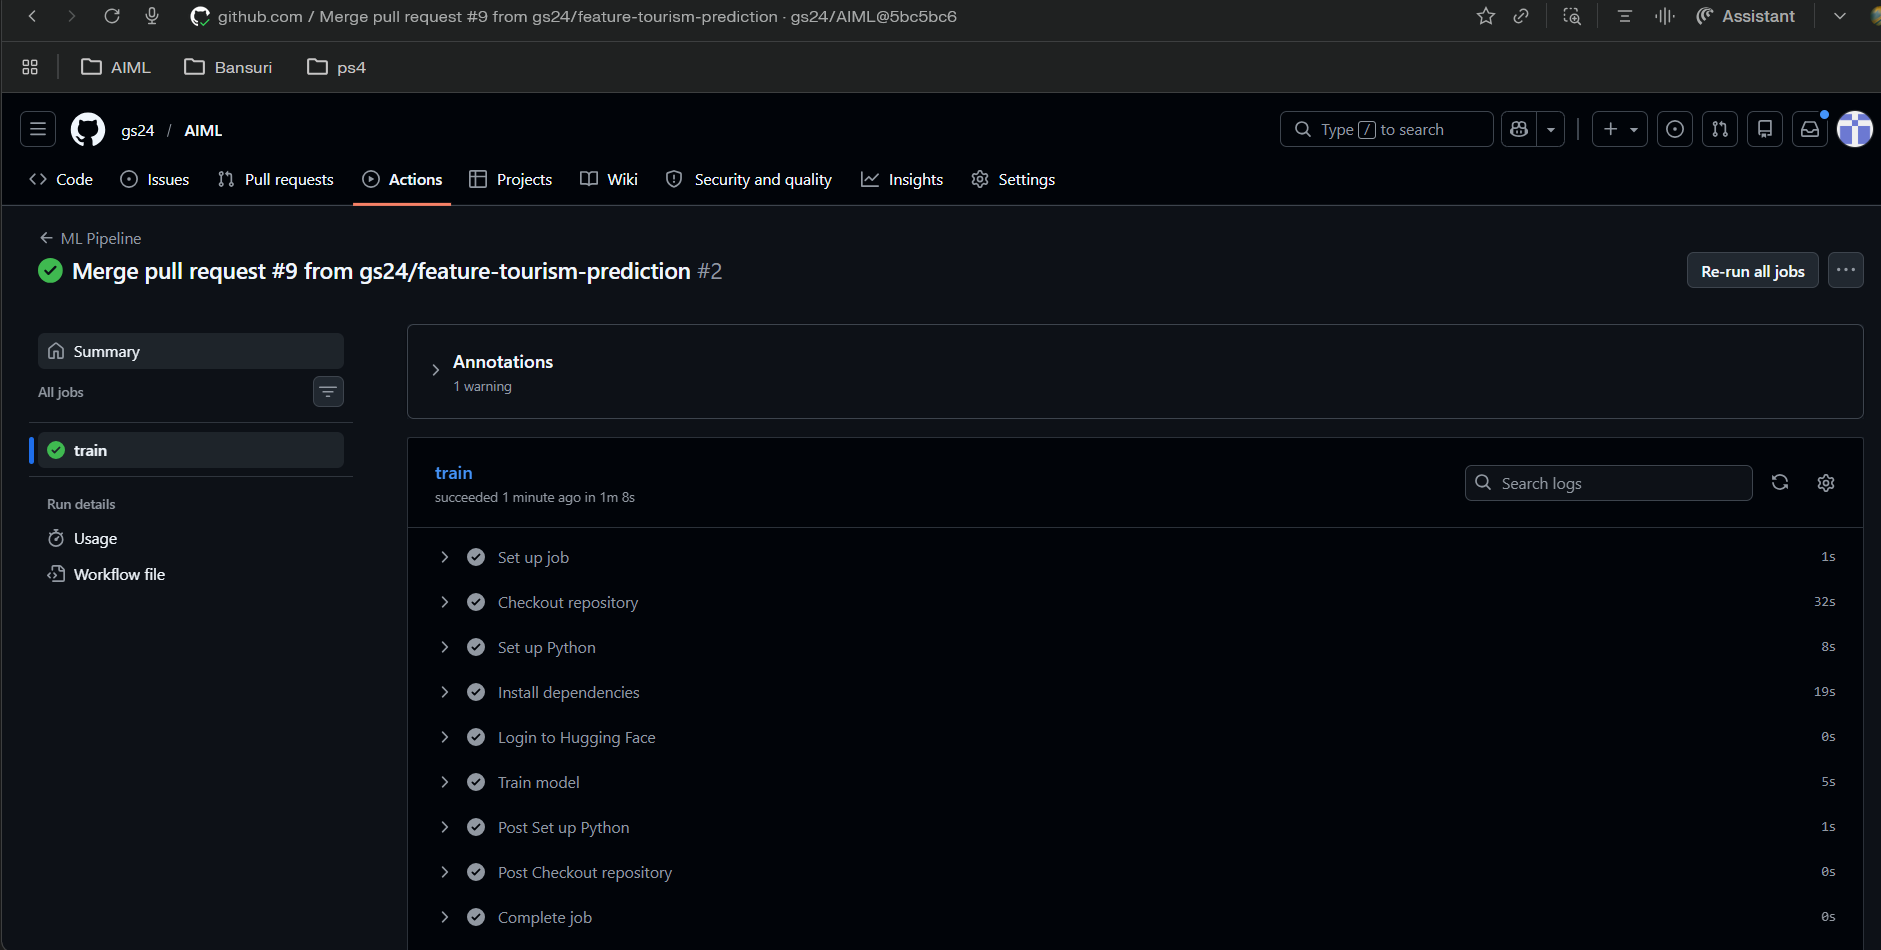

GitHub Actions was used to automate the machine learning pipeline. The workflow installs dependencies, loads the dataset from Hugging Face, trains the model, and uploads the trained model to the Hugging Face Model Hub. The pipeline is triggered automatically whenever changes are pushed to the main branch, enabling continuous integration and continuous deployment (CI/CD).

## Results

## Conclusion